Clustering Analysis – Customer Segmentation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [3]:
# Load the dataset
file_path = r"C:\Users\debja\OneDrive\Desktop\DA Python Pandas Projects\Main Flow Internship tasks\Task 3\customer_data.csv"

In [5]:
df = pd.read_csv(file_path)

In [7]:
# Inspect dataset
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nData Types:\n", df.dtypes)
print("\nSummary Statistics:\n", df.describe())

Dataset Shape: (200, 5)

Missing Values:
 CustomerID            0
Genre                 0
Age                   0
Annual_Income_(k$)    0
Spending_Score        0
dtype: int64

Duplicate Rows: 0

Data Types:
 CustomerID             int64
Genre                 object
Age                    int64
Annual_Income_(k$)     int64
Spending_Score         int64
dtype: object

Summary Statistics:
        CustomerID         Age  Annual_Income_(k$)  Spending_Score
count  200.000000  200.000000          200.000000      200.000000
mean   100.500000   38.850000           60.560000       50.200000
std     57.879185   13.969007           26.264721       25.823522
min      1.000000   18.000000           15.000000        1.000000
25%     50.750000   28.750000           41.500000       34.750000
50%    100.500000   36.000000           61.500000       50.000000
75%    150.250000   49.000000           78.000000       73.000000
max    200.000000   70.000000          137.000000       99.000000


In [9]:
# Drop CustomerID as it's not useful for clustering
df = df.drop(columns=['CustomerID'])

In [11]:
# Encode categorical variables
label_encoder = LabelEncoder()
df['Genre'] = label_encoder.fit_transform(df['Genre'])

In [13]:
# Standardize numerical features
scaler = StandardScaler()
df[['Age', 'Annual_Income_(k$)', 'Spending_Score']] = scaler.fit_transform(df[['Age', 'Annual_Income_(k$)', 'Spending_Score']])

In [15]:
# Determine optimal number of clusters using Elbow Method
wcss = []
cluster_range = range(1, 11)
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)

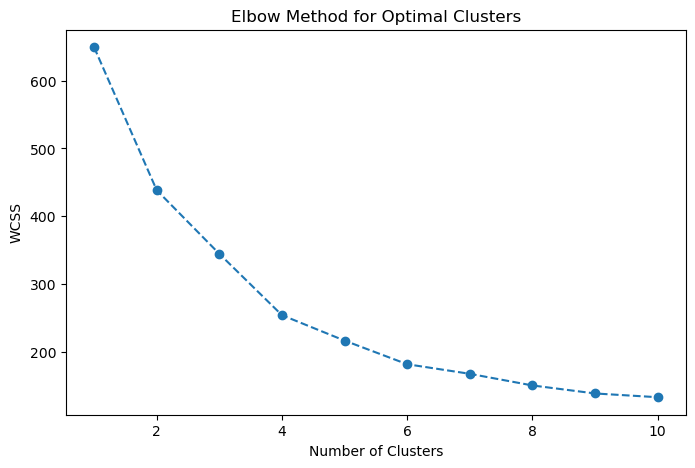

In [17]:
# Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal Clusters')
plt.show()

In [19]:
# Determine optimal clusters using Silhouette Score
silhouette_scores = {}
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df)
    score = silhouette_score(df, cluster_labels)
    silhouette_scores[k] = score

print("\nSilhouette Scores:", silhouette_scores)


Silhouette Scores: {2: 0.30319765641607577, 3: 0.3150351420814524, 4: 0.35027020434653977, 5: 0.34977050035201074, 6: 0.356485834425401, 7: 0.343309990954445, 8: 0.330422419595931, 9: 0.33996050475966766, 10: 0.30866345259814115}


In [21]:
# Apply K-Means with the optimal number of clusters (based on Elbow & Silhouette)
optimal_k = 6  # Chosen based on the highest silhouette score
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df)

In [23]:
# Reduce dimensions using PCA for visualization
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df.drop(columns=['Cluster']))

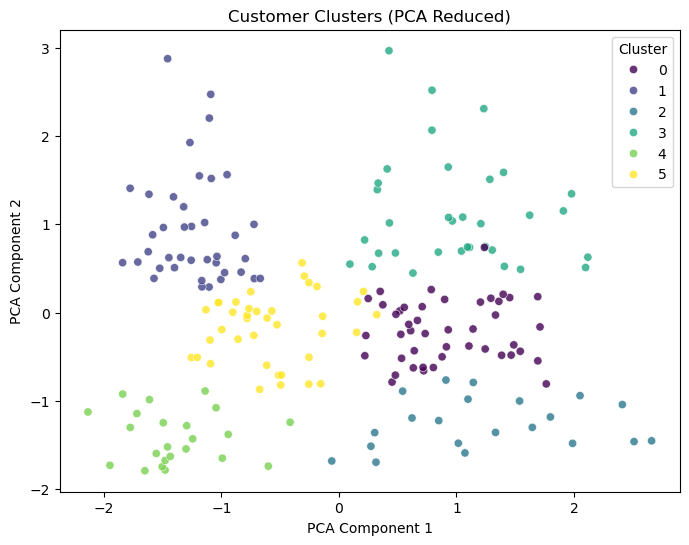

In [25]:
# Scatter plot of clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=df['Cluster'], palette='viridis', alpha=0.8)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Clusters (PCA Reduced)')
plt.legend(title='Cluster')
plt.show()

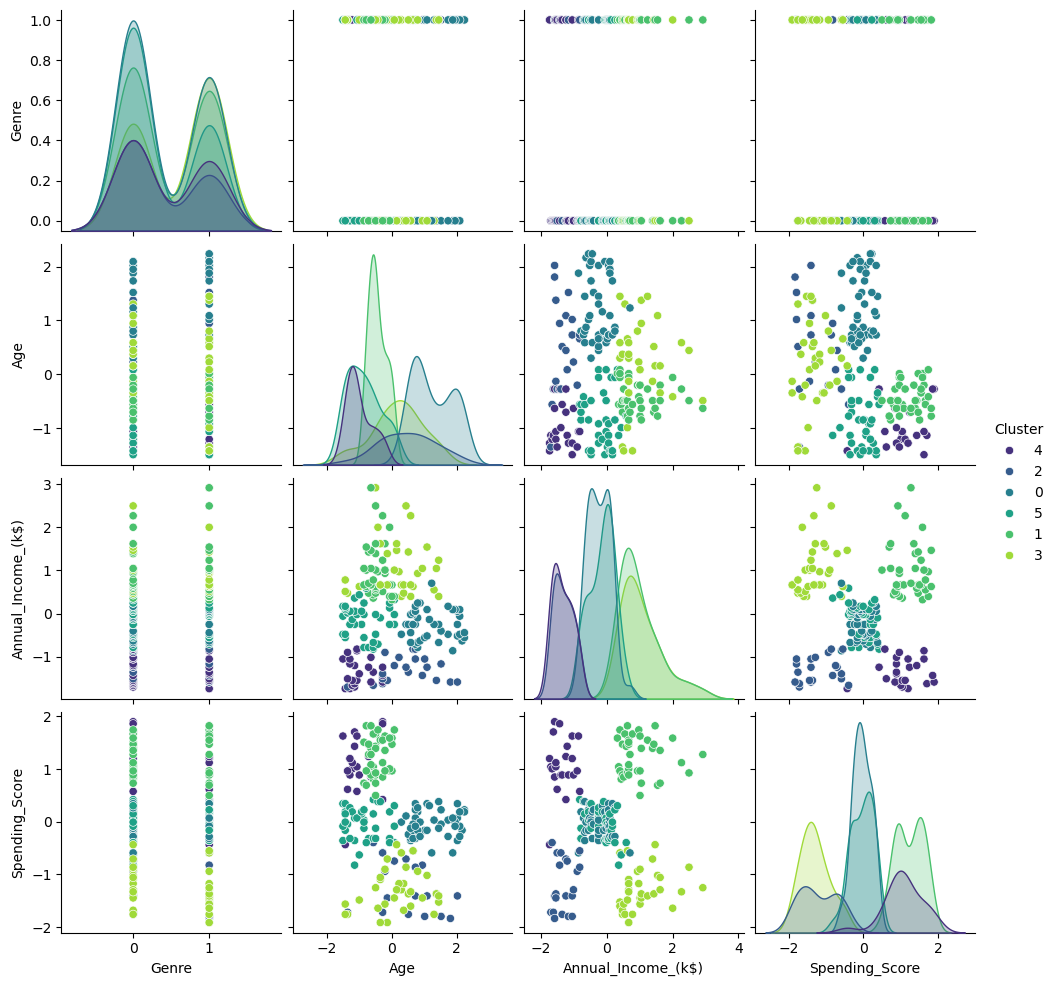

In [27]:
# Pair plot visualization of clusters
df['Cluster'] = df['Cluster'].astype(str)  # Convert to string for hue coloring
sns.pairplot(df, hue='Cluster', palette='viridis', diag_kind='kde')
plt.show()

In [29]:
# Print final dataset with clusters
print("\nFinal Clustered Dataset:")
print(df.head())


Final Clustered Dataset:
   Genre       Age  Annual_Income_(k$)  Spending_Score Cluster
0      1 -1.424569           -1.738999       -0.434801       4
1      1 -1.281035           -1.738999        1.195704       4
2      0 -1.352802           -1.700830       -1.715913       2
3      0 -1.137502           -1.700830        1.040418       4
4      0 -0.563369           -1.662660       -0.395980       2
